# BlazeX Multi-page Marketplace Analysis

Notebook này dùng để phân tích **nhiều file HTML** đã crawl từ các trang:

```text
raw/html/page_1.html
raw/html/page_2.html
...
```

Pipeline:
1. Đọc toàn bộ HTML trong `raw/html/`
2. Parse các product card
3. Gộp dữ liệu nhiều page
4. Loại duplicate
5. Phân loại sản phẩm
6. Thống kê
7. Vẽ biểu đồ
8. Xuất CSV + report

> Notebook chỉ xử lý file HTML đã lưu sẵn, không truy cập lại dark web.


## 1. Cài thư viện nếu cần

In [3]:
# Nếu thiếu thư viện thì mở comment dòng dưới và chạy
# !pip install beautifulsoup4 pandas matplotlib lxml

## 2. Import thư viện và cấu hình

In [4]:
from bs4 import BeautifulSoup
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ===== CONFIG =====
HTML_DIR = Path("raw/html")

OUT_DIR = Path("processed")
CHART_DIR = Path("charts")

OUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

CSV_FILE = OUT_DIR / "blazex_multi_page_products.csv"
REPORT_FILE = OUT_DIR / "multi_page_analysis_report.txt"

print("HTML folder:", HTML_DIR)
print("Output folder:", OUT_DIR)
print("Chart folder:", CHART_DIR)


HTML folder: raw/html
Output folder: processed
Chart folder: charts


## 3. Kiểm tra các file HTML đã crawl

In [5]:
html_files = sorted(HTML_DIR.glob("*.html"))

if not html_files:
    raise FileNotFoundError(
        f"Không tìm thấy file HTML nào trong {HTML_DIR}. "
        "Hãy kiểm tra lại thư mục raw/html/"
    )

print(f"Tìm thấy {len(html_files)} file HTML:")
for f in html_files:
    print("-", f, f"({f.stat().st_size/1024:.2f} KB)")


Tìm thấy 4 file HTML:
- raw/html/page_1.html (25.02 KB)
- raw/html/page_2.html (25.12 KB)
- raw/html/page_3.html (25.04 KB)
- raw/html/page_5.html (12.46 KB)


## 4. Hàm xử lý, trích xuất và phân loại

In [6]:
def clean_text(text):
    if not text:
        return None
    return re.sub(r"\s+", " ", text).strip()


def extract_price(price_text):
    if not price_text:
        return None
    price_text = price_text.replace("$", "").replace(",", "").strip()
    try:
        return float(price_text)
    except ValueError:
        return None


def classify_product(title):
    title_lower = (title or "").lower()

    if any(k in title_lower for k in ["spotify", "hbo", "netflix", "disney", "youtube", "max"]):
        return "Streaming Account"

    if any(k in title_lower for k in ["chatgpt", "openai", "claude", "gemini", "ai account"]):
        return "AI Account"

    if any(k in title_lower for k in ["windows", "office", "adobe", "creative cloud", "license", "activator", "key"]):
        return "Software / License"

    if any(k in title_lower for k in ["xbox", "game pass", "steam", "epic", "riot", "gaming"]):
        return "Gaming Account"

    if any(k in title_lower for k in ["discord", "telegram", "whatsapp", "signal"]):
        return "Communication Account"

    if any(k in title_lower for k in ["mega", "cloud", "email", "gmail", "storage"]):
        return "Cloud / Storage"

    if any(k in title_lower for k in ["vpn", "rdp", "proxy"]):
        return "Network / VPN"

    if any(k in title_lower for k in ["porn", "adult", "18+", "webmodels"]):
        return "Adult Account"

    if any(k in title_lower for k in ["sim", "activation", "phone"]):
        return "Activation Service"

    return "Other"


def get_price_level(price):
    if pd.isna(price):
        return "Unknown"
    if price < 5:
        return "Very Low (< $5)"
    if price < 15:
        return "Low ($5 - $15)"
    if price < 50:
        return "Medium ($15 - $50)"
    return "High (> $50)"


def parse_product_card(card, source_file):
    title_tag = card.find("h3", class_="product-card-name")
    price_tag = card.find("div", class_="product-card-price-badge")

    title = clean_text(title_tag.get_text()) if title_tag else None
    price = extract_price(price_tag.get_text()) if price_tag else None

    href = card.get("href")
    all_text = clean_text(card.get_text(" "))

    sales = None
    m = re.search(r"Sales\s+(\d+)", all_text or "", re.I)
    if m:
        sales = int(m.group(1))

    done_rate = None
    m = re.search(r"Done\s+([\d.]+)%", all_text or "", re.I)
    if m:
        done_rate = float(m.group(1))

    vendor_cancels = None
    m = re.search(r"Vendor Cancels:\s*(\d+)", all_text or "", re.I)
    if m:
        vendor_cancels = int(m.group(1))

    age_days = None
    m = re.search(r"Age\s+(\d+)\s+Days", all_text or "", re.I)
    if m:
        age_days = int(m.group(1))

    bond = None
    m = re.search(r"Bond\s+(.*?)\s+Sales", all_text or "", re.I)
    if m:
        bond = clean_text(m.group(1))

    is_digital = "DIGITAL" in (all_text or "").upper()
    is_instant = "INSTANT" in (all_text or "").upper()
    is_adult = ("18+" in (all_text or "")) or ("porn" in (title or "").lower())

    category = classify_product(title)
    price_level = get_price_level(price)

    return {
        "source_file": source_file,
        "title": title,
        "price_usd": price,
        "category": category,
        "price_level": price_level,
        "is_digital": is_digital,
        "is_instant": is_instant,
        "is_adult": is_adult,
        "bond": bond,
        "sales": sales,
        "done_rate": done_rate,
        "vendor_cancels": vendor_cancels,
        "age_days": age_days,
        "product_url": href,
        "raw_text": all_text
    }


## 5. Parse toàn bộ file HTML và merge thành 1 DataFrame

In [7]:
rows = []
page_stats = []

for html_file in html_files:
    html = html_file.read_text(encoding="utf-8", errors="ignore")
    soup = BeautifulSoup(html, "html.parser")

    product_cards = soup.find_all("a", class_="product-card")
    page_stats.append({
        "source_file": html_file.name,
        "product_cards_found": len(product_cards)
    })

    for card in product_cards:
        rows.append(parse_product_card(card, html_file.name))

df_raw = pd.DataFrame(rows)
page_stats_df = pd.DataFrame(page_stats)

print("Tổng product cards trước khi bỏ trùng:", len(df_raw))
display(page_stats_df)

df_raw.head(10)


Tổng product cards trước khi bỏ trùng: 40


,source_file,product_cards_found
0,page_1.html,12
1,page_2.html,12
2,page_3.html,12
3,page_5.html,4


,source_file,title,price_usd,category,price_level,is_digital,is_instant,is_adult,bond,sales,done_rate,vendor_cancels,age_days,product_url,raw_text
0,page_1.html,Proxy Shopper Service – UK Shop or Locker Deli...,NaN,Network / VPN,Unknown,True,False,False,0.2 XMR,0,NaN,0,65,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Proxy Shopper Service – UK Shop or Locker Deli...
1,page_1.html,Adobe Creative Cloud All Apps For 3 Months,28.00,Software / License,Medium ($15 - $50),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Adobe Creative Cloud All Apps For 3 Months $28...
2,page_1.html,15 random physical PAYG sims for number verifi...,NaN,Activation Service,Unknown,False,False,False,0.15 XMR,0,NaN,0,64,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,15 random physical PAYG sims for number verifi...
3,page_1.html,Tidal 6 Month Individual Account,NaN,Other,Unknown,True,True,False,Not bonded,1,100.0,0,6,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Tidal 6 Month Individual Account ɱ0.045 DIGITA...
4,page_1.html,Tidal 3 Months Individual,NaN,Other,Unknown,True,True,False,Not bonded,1,100.0,0,6,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Tidal 3 Months Individual ɱ0.0091617737 DIGITA...
5,page_1.html,Nord Vpn account,5.00,Network / VPN,Low ($5 - $15),True,False,False,0.1 XMR,4,100.0,0,70,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Nord Vpn account $5.00 DIGITAL Bond 0.1 XMR Sa...
6,page_1.html,Windows 10 Pro License Key,5.00,Software / License,Low ($5 - $15),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Windows 10 Pro License Key $5.00 DIGITAL Bond ...
7,page_1.html,Whatsapp/Telegram Activation with Physical sim,13.00,Communication Account,Low ($5 - $15),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Whatsapp/Telegram Activation with Physical sim...
8,page_1.html,Spotify Account Bundle (Free Tier),0.75,Streaming Account,Very Low (< $5),True,True,False,Not bonded,3,100.0,0,24,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Spotify Account Bundle (Free Tier) $0.75 DIGIT...
9,page_1.html,Telegram account | manual delivery,5.00,Communication Account,Low ($5 - $15),True,False,False,0.1 XMR,4,100.0,0,70,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Telegram account | manual delivery $5.00 DIGIT...


## 6. Làm sạch dữ liệu và bỏ duplicate

In [8]:
df = df_raw.copy()

# Bỏ dòng thiếu title hoặc price
df = df.dropna(subset=["title", "price_usd"])

# Bỏ duplicate theo URL nếu có; nếu URL trống thì fallback theo title + price
if "product_url" in df.columns and df["product_url"].notna().any():
    df = df.drop_duplicates(subset=["product_url"])
else:
    df = df.drop_duplicates(subset=["title", "price_usd"])

df = df.reset_index(drop=True)

# Đảm bảo kiểu dữ liệu số
for col in ["price_usd", "sales", "done_rate", "vendor_cancels", "age_days"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Số sản phẩm sau khi làm sạch:", len(df))
df.head(20)


Số sản phẩm sau khi làm sạch: 25


,source_file,title,price_usd,category,price_level,is_digital,is_instant,is_adult,bond,sales,done_rate,vendor_cancels,age_days,product_url,raw_text
0,page_1.html,Adobe Creative Cloud All Apps For 3 Months,28.00,Software / License,Medium ($15 - $50),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Adobe Creative Cloud All Apps For 3 Months $28...
1,page_1.html,Nord Vpn account,5.00,Network / VPN,Low ($5 - $15),True,False,False,0.1 XMR,4,100.0,0,70,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Nord Vpn account $5.00 DIGITAL Bond 0.1 XMR Sa...
2,page_1.html,Windows 10 Pro License Key,5.00,Software / License,Low ($5 - $15),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Windows 10 Pro License Key $5.00 DIGITAL Bond ...
3,page_1.html,Whatsapp/Telegram Activation with Physical sim,13.00,Communication Account,Low ($5 - $15),True,False,False,Not bonded,1,100.0,0,22,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Whatsapp/Telegram Activation with Physical sim...
4,page_1.html,Spotify Account Bundle (Free Tier),0.75,Streaming Account,Very Low (< $5),True,True,False,Not bonded,3,100.0,0,24,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Spotify Account Bundle (Free Tier) $0.75 DIGIT...
5,page_1.html,Telegram account | manual delivery,5.00,Communication Account,Low ($5 - $15),True,False,False,0.1 XMR,4,100.0,0,70,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Telegram account | manual delivery $5.00 DIGIT...
6,page_1.html,OnlyFans Account Email Verified Including Emai...,2.50,Cloud / Storage,Very Low (< $5),True,True,False,Not bonded,3,100.0,0,24,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,OnlyFans Account Email Verified Including Emai...
7,page_1.html,Windows 11 Home product key,6.00,Software / License,Low ($5 - $15),True,True,False,Not bonded,0,NaN,0,66,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,Windows 11 Home product key $6.00 DIGITAL INST...
8,page_2.html,ChatGPT Account Bundle On Demand (Free Tier),0.80,AI Account,Very Low (< $5),True,True,False,Not bonded,3,100.0,0,24,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,ChatGPT Account Bundle On Demand (Free Tier) $...
9,page_2.html,"Proton VPN , free account",0.50,Network / VPN,Very Low (< $5),True,True,False,0.1 XMR,4,100.0,0,70,http://gc3ygt7m2xtjicadvsyxopwo6aamvt2qnapnuym...,"Proton VPN , free account $0.50 DIGITAL INSTAN..."


## 7. Lưu dataset merged ra CSV

In [9]:
df.to_csv(CSV_FILE, index=False)
print(f"Đã lưu dataset merged: {CSV_FILE}")


Đã lưu dataset merged: processed/blazex_multi_page_products.csv


## 8. Tổng quan dataset

In [10]:
overview = {
    "total_html_files": len(html_files),
    "raw_product_cards": len(df_raw),
    "clean_unique_products": len(df),
    "average_price_usd": round(df["price_usd"].mean(), 2),
    "median_price_usd": round(df["price_usd"].median(), 2),
    "min_price_usd": round(df["price_usd"].min(), 2),
    "max_price_usd": round(df["price_usd"].max(), 2),
    "average_sales": round(df["sales"].mean(), 2),
    "average_vendor_age_days": round(df["age_days"].mean(), 2),
    "digital_products": int(df["is_digital"].sum()),
    "instant_products": int(df["is_instant"].sum()),
    "adult_products": int(df["is_adult"].sum()),
}

overview_df = pd.DataFrame([overview])
overview_df


,total_html_files,raw_product_cards,clean_unique_products,average_price_usd,median_price_usd,min_price_usd,max_price_usd,average_sales,average_vendor_age_days,digital_products,instant_products,adult_products
0,4,40,25,8.46,6.25,0.5,55.0,2.12,44.56,25,8,4


## 9. Thống kê category, mức giá, trạng thái instant/digital

In [11]:
category_count = df["category"].value_counts()
price_level_count = df["price_level"].value_counts()
instant_count = df["is_instant"].map({True: "Instant", False: "Non-Instant"}).value_counts()
digital_count = df["is_digital"].map({True: "Digital", False: "Non-Digital"}).value_counts()

display(category_count.to_frame("count"))
display(price_level_count.to_frame("count"))
display(instant_count.to_frame("count"))
display(digital_count.to_frame("count"))


,count
category,
Software / License,7
AI Account,4
Adult Account,4
Network / VPN,2
Communication Account,2
Streaming Account,2
Cloud / Storage,2
Other,2


,count
price_level,
Low ($5 - $15),16
Very Low (< $5),7
Medium ($15 - $50),1
High (> $50),1


,count
is_instant,
Non-Instant,17
Instant,8


,count
is_digital,
Digital,25


## 10. Top sản phẩm theo giá và theo lượt bán

In [12]:
top_expensive = df.sort_values("price_usd", ascending=False)[
    ["title", "category", "price_usd", "sales", "age_days", "is_instant", "bond", "source_file"]
].head(15)

top_sales = df.sort_values("sales", ascending=False)[
    ["title", "category", "price_usd", "sales", "age_days", "is_instant", "bond", "source_file"]
].head(15)

print("Top expensive products")
display(top_expensive)

print("Top sales products")
display(top_sales)


Top expensive products


,title,category,price_usd,sales,age_days,is_instant,bond,source_file
18,Adobe Creative Cloud All Apps For 6 Months,Software / License,55.00,1,22,False,Not bonded,page_3.html
0,Adobe Creative Cloud All Apps For 3 Months,Software / License,28.00,1,22,False,Not bonded,page_1.html
3,Whatsapp/Telegram Activation with Physical sim,Communication Account,13.00,1,22,False,Not bonded,page_1.html
20,Canva Pro Lifetime,Other,10.00,1,22,False,Not bonded,page_3.html
22,MalwareBytes Premium Key,Software / License,9.00,4,70,False,0.1 XMR,page_3.html
16,Abbywinters Porn Premium Account,Adult Account,9.00,0,65,False,0.05 XMR,page_2.html
11,DetentionGirls.com Premium Porn Account,Adult Account,9.00,0,65,False,0.05 XMR,page_2.html
15,Tokyobang.com Porn Account,Adult Account,9.00,0,65,False,0.05 XMR,page_2.html
23,ADOBE PHOTOSHOP 2024 ~ FULLY FUNCTIONAL,Software / License,8.00,4,70,False,0.1 XMR,page_3.html
17,girlsoutwest.com Porn Account,Adult Account,8.00,0,65,False,0.05 XMR,page_3.html


Top sales products


,title,category,price_usd,sales,age_days,is_instant,bond,source_file
12,HBO Max Premium Account,Streaming Account,5.00,4,70,False,0.1 XMR,page_2.html
9,"Proton VPN , free account",Network / VPN,0.50,4,70,True,0.1 XMR,page_2.html
23,ADOBE PHOTOSHOP 2024 ~ FULLY FUNCTIONAL,Software / License,8.00,4,70,False,0.1 XMR,page_3.html
22,MalwareBytes Premium Key,Software / License,9.00,4,70,False,0.1 XMR,page_3.html
5,Telegram account | manual delivery,Communication Account,5.00,4,70,False,0.1 XMR,page_1.html
14,All Windows Microsoft Office activator key,Software / License,7.00,4,70,False,0.1 XMR,page_2.html
1,Nord Vpn account,Network / VPN,5.00,4,70,False,0.1 XMR,page_1.html
21,Grok AI Account Bundle On Demand (Free Tier),AI Account,0.77,3,24,True,Not bonded,page_3.html
10,ChatGPT Account Bundle On Demand (Free Tier),AI Account,1.00,3,24,True,Not bonded,page_2.html
24,Claude AI Account Bundle On Demand (Free Tier),AI Account,0.90,3,24,True,Not bonded,page_5.html


## 11. Phân tích theo category

In [13]:
category_analysis = (
    df.groupby("category")
    .agg(
        product_count=("title", "count"),
        avg_price=("price_usd", "mean"),
        median_price=("price_usd", "median"),
        min_price=("price_usd", "min"),
        max_price=("price_usd", "max"),
        total_sales=("sales", "sum"),
        avg_sales=("sales", "mean"),
        avg_vendor_age=("age_days", "mean"),
    )
    .sort_values("product_count", ascending=False)
)

category_analysis = category_analysis.round(2)
display(category_analysis)


,product_count,avg_price,median_price,min_price,max_price,total_sales,avg_sales,avg_vendor_age
category,,,,,,,,
Software / License,7,16.86,8.00,5.00,55.00,15,2.14,48.86
AI Account,4,0.87,0.85,0.77,1.00,12,3.00,24.00
Adult Account,4,8.75,9.00,8.00,9.00,0,0.00,65.00
Cloud / Storage,2,4.38,4.38,2.50,6.25,4,2.00,23.00
Communication Account,2,9.00,9.00,5.00,13.00,5,2.50,46.00
Network / VPN,2,2.75,2.75,0.50,5.00,8,4.00,70.00
Other,2,8.50,8.50,7.00,10.00,2,1.00,22.00
Streaming Account,2,2.88,2.88,0.75,5.00,7,3.50,47.00


## 12. Xuất report text

In [14]:
summary = []

summary.append("===== BLAZEX MULTI-PAGE MARKETPLACE ANALYSIS REPORT =====\n")
summary.append(f"Total HTML files: {len(html_files)}")
summary.append(f"Raw product cards: {len(df_raw)}")
summary.append(f"Clean unique products: {len(df)}")
summary.append(f"Average price: ${df['price_usd'].mean():.2f}")
summary.append(f"Median price: ${df['price_usd'].median():.2f}")
summary.append(f"Min price: ${df['price_usd'].min():.2f}")
summary.append(f"Max price: ${df['price_usd'].max():.2f}")
summary.append(f"Average sales: {df['sales'].mean():.2f}")
summary.append(f"Average vendor age: {df['age_days'].mean():.2f} days")
summary.append(f"Digital products: {int(df['is_digital'].sum())}")
summary.append(f"Instant products: {int(df['is_instant'].sum())}")

summary.append("\n===== Page Stats =====")
summary.append(str(page_stats_df))

summary.append("\n===== Category Count =====")
summary.append(str(category_count))

summary.append("\n===== Price Level Count =====")
summary.append(str(price_level_count))

summary.append("\n===== Category Analysis =====")
summary.append(str(category_analysis))

summary.append("\n===== Top Expensive Products =====")
summary.append(str(top_expensive))

summary.append("\n===== Top Sales Products =====")
summary.append(str(top_sales))

REPORT_FILE.write_text("\n".join(summary), encoding="utf-8")

print(f"Đã lưu report: {REPORT_FILE}")


Đã lưu report: processed/multi_page_analysis_report.txt


# 13. Vẽ biểu đồ

## 13.1. Số sản phẩm theo category

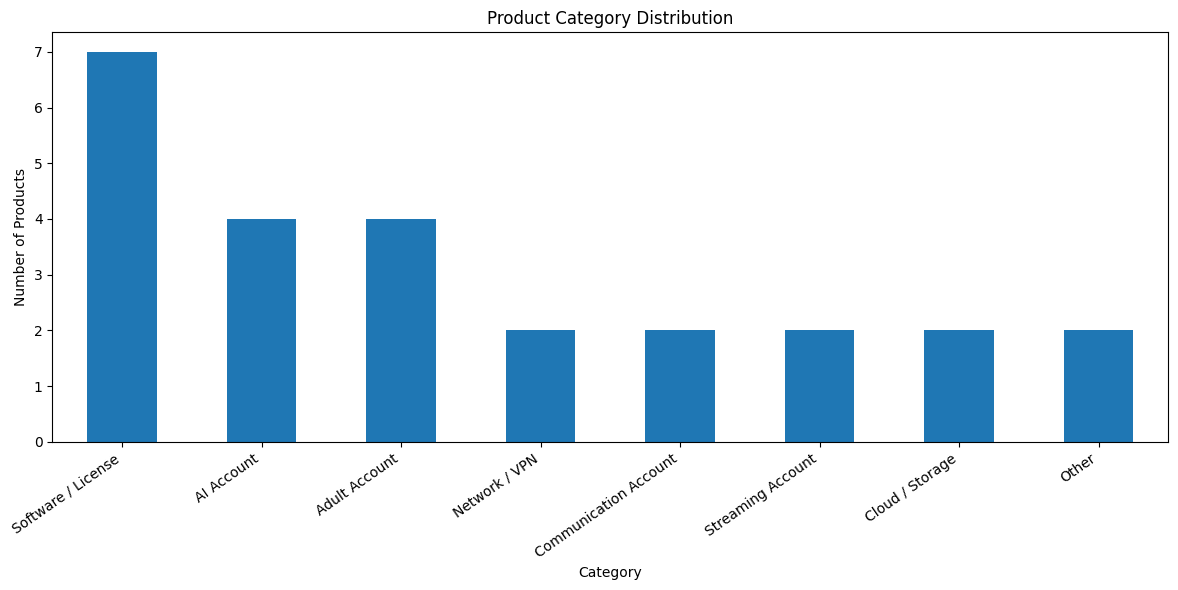

In [15]:
plt.figure(figsize=(12, 6))
category_count.plot(kind="bar")
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_category_distribution.png", dpi=300)
plt.show()


## 13.2. Phân bố giá

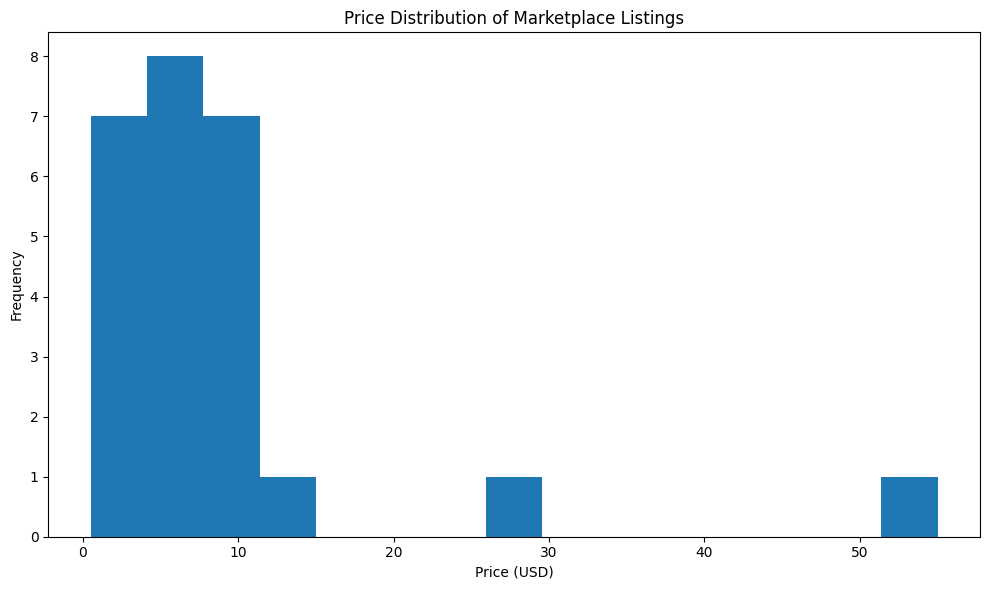

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df["price_usd"].dropna(), bins=15)
plt.title("Price Distribution of Marketplace Listings")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_price_distribution.png", dpi=300)
plt.show()


## 13.3. Giá trung bình theo category

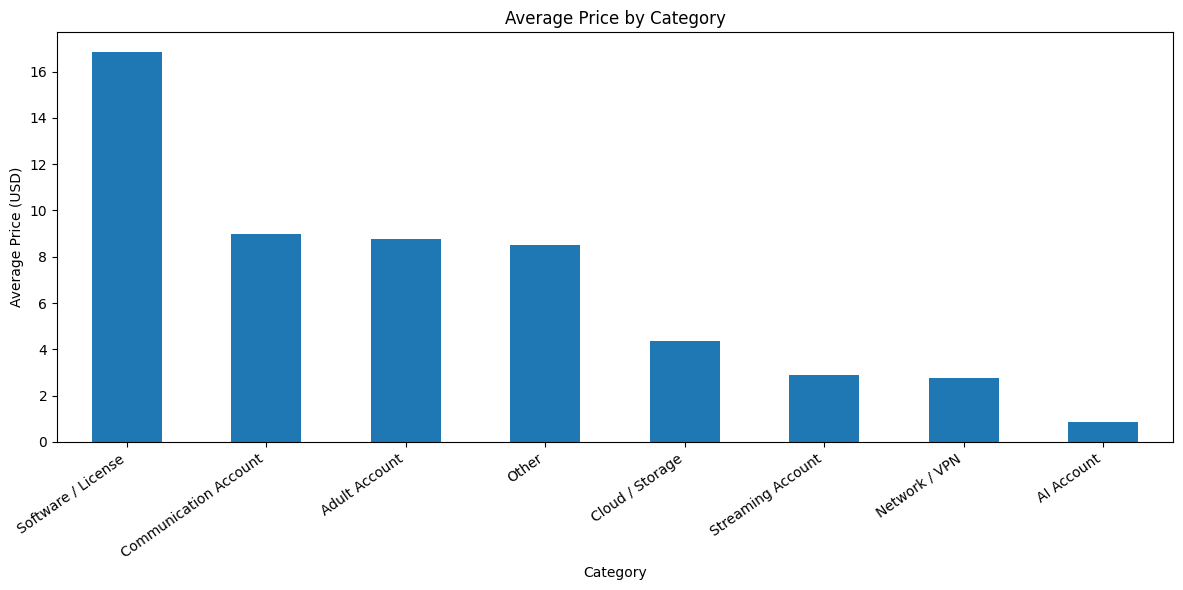

In [17]:
avg_price = df.groupby("category")["price_usd"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price.plot(kind="bar")
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_average_price_by_category.png", dpi=300)
plt.show()


## 13.4. Top 15 sản phẩm đắt nhất

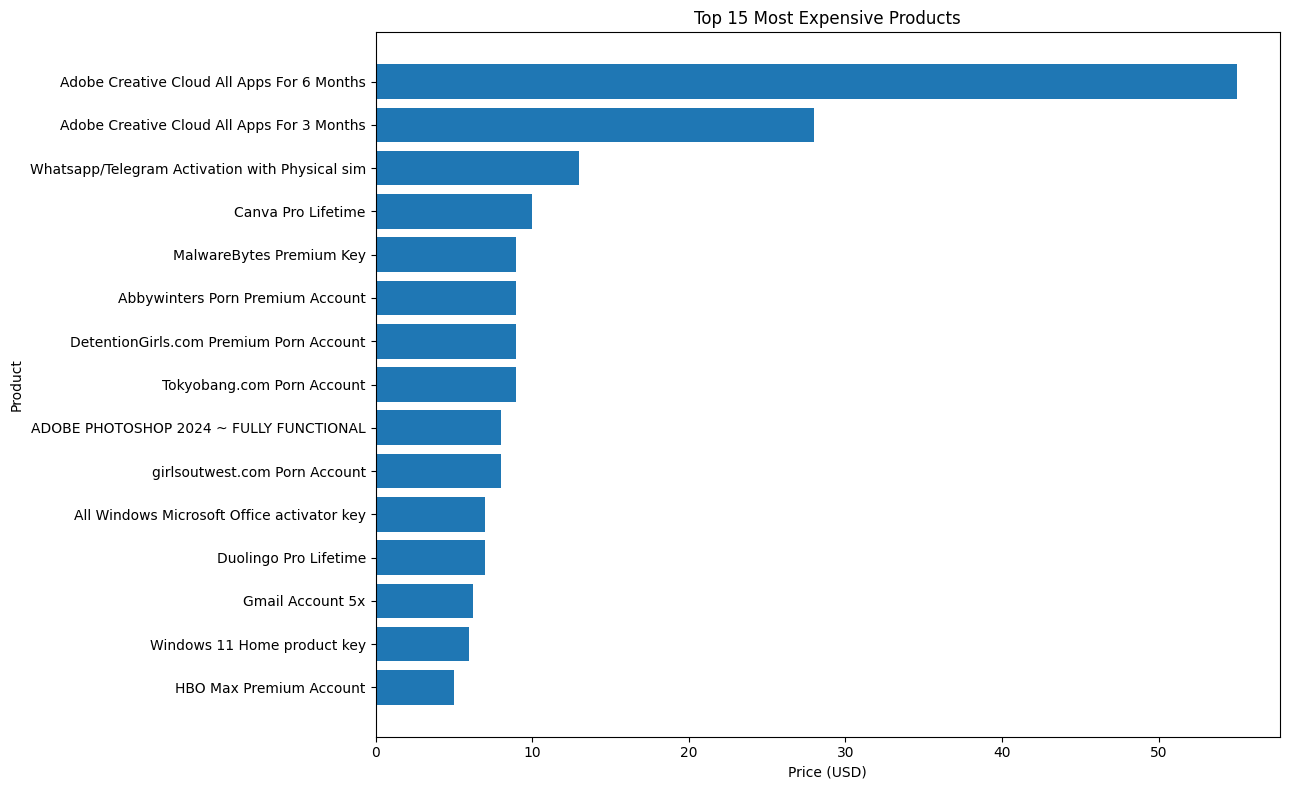

In [18]:
top_price_chart = df.sort_values("price_usd", ascending=False).head(15)

plt.figure(figsize=(13, 8))
plt.barh(top_price_chart["title"], top_price_chart["price_usd"])
plt.title("Top 15 Most Expensive Products")
plt.xlabel("Price (USD)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHART_DIR / "04_top_expensive_products.png", dpi=300)
plt.show()


## 13.5. Top 15 sản phẩm theo sales

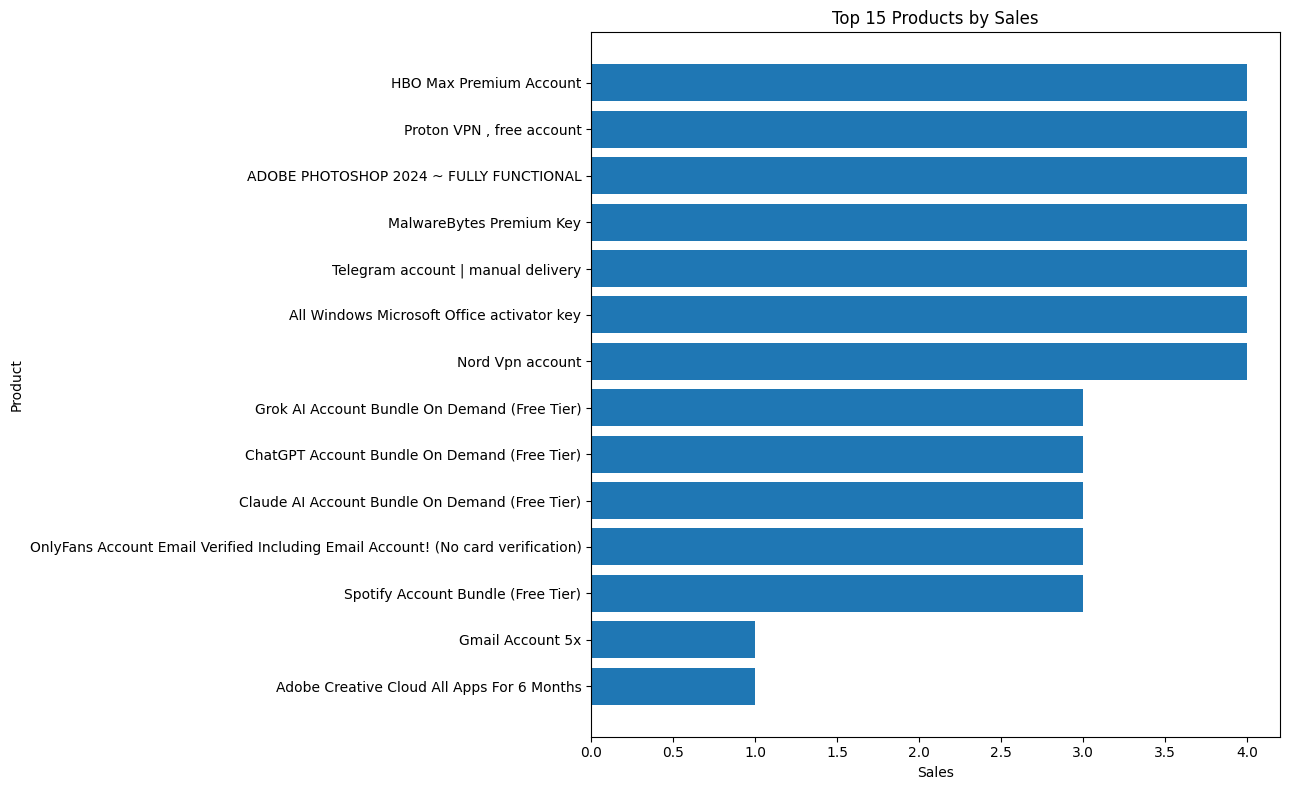

In [19]:
top_sales_chart = df.sort_values("sales", ascending=False).head(15)

plt.figure(figsize=(13, 8))
plt.barh(top_sales_chart["title"], top_sales_chart["sales"])
plt.title("Top 15 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHART_DIR / "05_top_sales_products.png", dpi=300)
plt.show()


## 13.6. Tỷ lệ mức giá

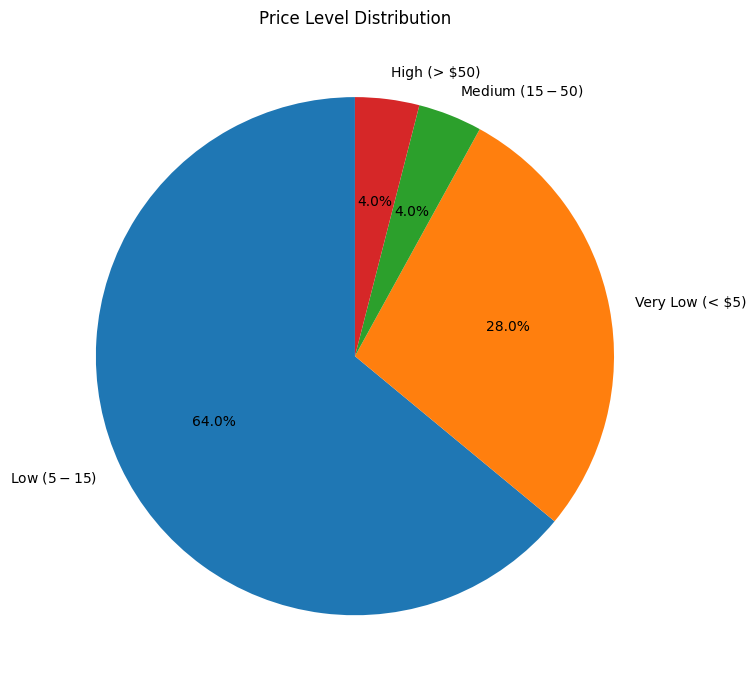

In [20]:
price_level_count = df["price_level"].value_counts()

plt.figure(figsize=(9, 7))
plt.pie(
    price_level_count.values,
    labels=price_level_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Price Level Distribution")
plt.tight_layout()
plt.savefig(CHART_DIR / "06_price_level_pie.png", dpi=300)
plt.show()


## 13.7. Price vs Sales

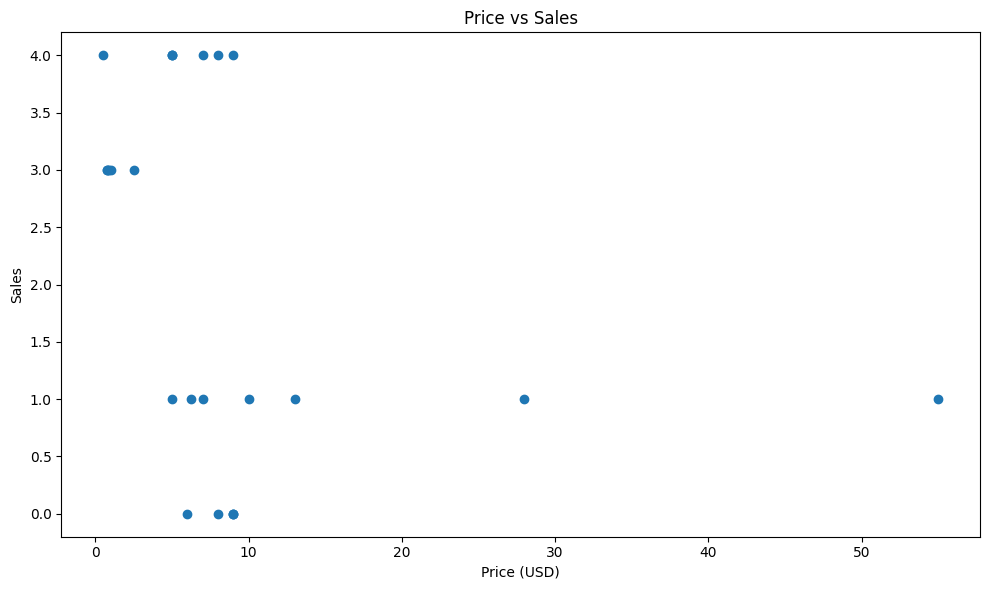

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df["price_usd"], df["sales"])
plt.title("Price vs Sales")
plt.xlabel("Price (USD)")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_price_vs_sales.png", dpi=300)
plt.show()


## 13.8. Instant vs Non-Instant

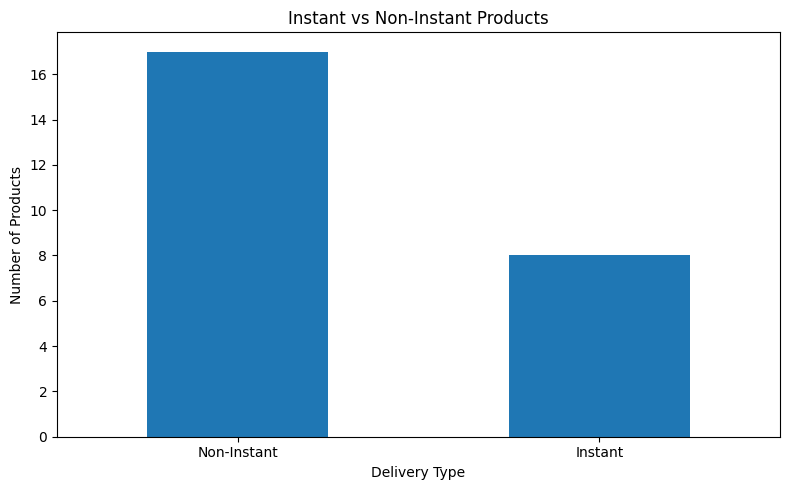

In [28]:
instant_count = df["is_instant"].map({True: "Instant", False: "Non-Instant"}).value_counts()

plt.figure(figsize=(8, 5))
instant_count.plot(kind="bar")
plt.title("Instant vs Non-Instant Products")
plt.xlabel("Delivery Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "09_instant_distribution.png", dpi=300)
plt.show()


## 13.9. Tổng sales theo category

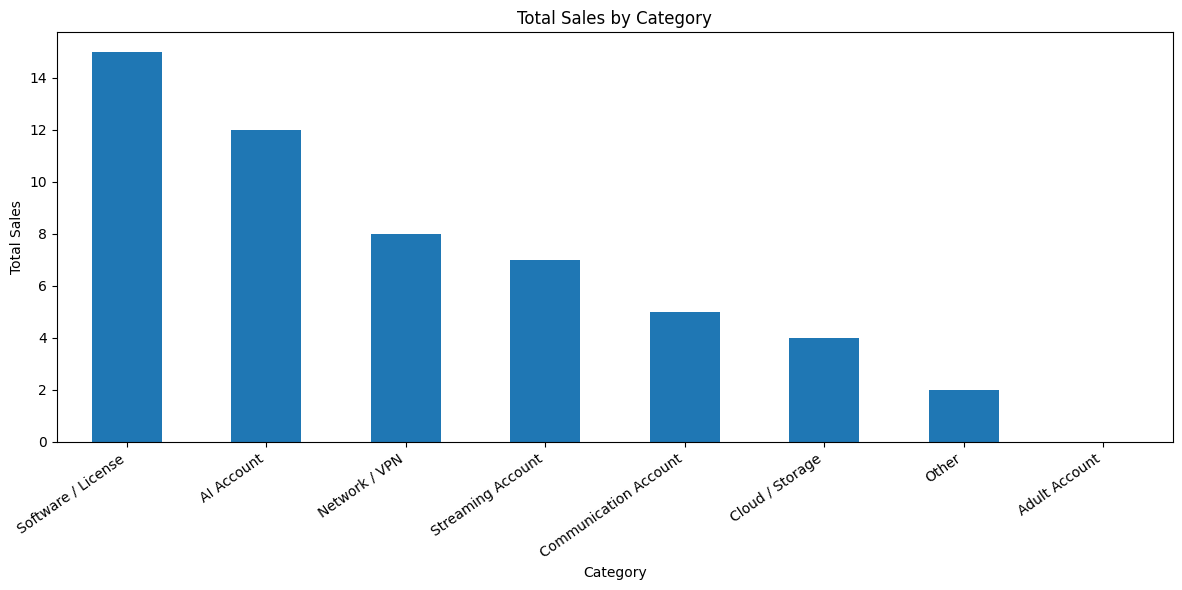

In [29]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sales_by_category.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "11_total_sales_by_category.png", dpi=300)
plt.show()


## 14. Kết luận tự động cho báo cáo

In [27]:
main_category = df["category"].value_counts().index[0] if len(df) else "N/A"

conclusion = f'''
Kết quả phân tích multi-page cho thấy dataset gồm {len(df)} sản phẩm duy nhất được trích xuất từ {len(html_files)} file HTML.
Nhóm sản phẩm xuất hiện nhiều nhất là "{main_category}".
Giá trung bình của các listing là khoảng ${df['price_usd'].mean():.2f}, giá trung vị là ${df['price_usd'].median():.2f}, và giá cao nhất là ${df['price_usd'].max():.2f}.
Các sản phẩm digital/instant chiếm tỷ lệ đáng kể, cho thấy marketplace tập trung nhiều vào hàng hóa số và tài khoản trực tuyến.
Các biểu đồ Category Distribution, Average Price by Category, Price Distribution, Price vs Sales và Vendor Age vs Sales hỗ trợ quan sát xu hướng giá, nhóm hàng phổ biến và mức độ hoạt động của vendor.
'''

print(conclusion)



Kết quả phân tích multi-page cho thấy dataset gồm 25 sản phẩm duy nhất được trích xuất từ 4 file HTML.
Nhóm sản phẩm xuất hiện nhiều nhất là "Software / License".
Giá trung bình của các listing là khoảng $8.46, giá trung vị là $6.25, và giá cao nhất là $55.00.
Các sản phẩm digital/instant chiếm tỷ lệ đáng kể, cho thấy marketplace tập trung nhiều vào hàng hóa số và tài khoản trực tuyến.
Các biểu đồ Category Distribution, Average Price by Category, Price Distribution, Price vs Sales và Vendor Age vs Sales hỗ trợ quan sát xu hướng giá, nhóm hàng phổ biến và mức độ hoạt động của vendor.

